# Deep Learning-Based Transfer Course Equivalency Prediction Using Structured Features and Knowledge Unit Similarity

## CST 361/461 – Deep Learning Final Project

### Project Overview
This project builds a deep learning pipeline to predict whether two college courses should be considered equivalent for transfer credit.

The system compares two neural network architectures:
1. TransferMatcherNet, which uses structured course features
2. NLPTransferMatcherNet, which uses Knowledge Unit and semantic similarity features

The notebook includes source code, model training, model comparison, multiple independent trials, visualizations, results, conclusion, and AI usage disclosure.

## Problem Statement

Transfer credit evaluation between universities is often a manual and time-consuming process. This project explores whether deep learning models can automatically predict course equivalency using structured academic information and semantic Knowledge Unit similarity.

The goal is to improve transfer matching accuracy while reducing manual review effort.


## Dataset and Features

The project uses:
- course metadata
- course credit information
- course subject and level information
- Knowledge Unit (KU) mappings
- semantic similarity features
- TF-IDF text similarity

CSV datasets include:
- courses.csv
- knowledge_units.csv
- course_ku.csv

The final feature pipelines generate:
- 19 structured academic features
- 14 NLP/KU semantic similarity features

## Deep Learning Architectures

Two deep learning architectures were implemented and compared in this project.

### 1. TransferMatcherNet
This feedforward neural network uses structured academic features such as:
- course level
- subject similarity
- credits
- prerequisite similarity
- engineered transfer features

The model uses:
- Linear layers
- ReLU activation
- Batch Normalization
- Dropout regularization
- Sigmoid output activation

### 2. NLPTransferMatcherNet
This neural network uses semantic and NLP-based features derived from:
- Knowledge Unit overlap
- TF-IDF similarity
- text-based semantic comparison

The architecture also uses:
- Linear layers
- ReLU activation
- Dropout regularization
- Sigmoid output activation

In [19]:
# Display the complete source code for the project
from IPython.display import Code

Code("transfer_matcher_full.py")

#!/usr/bin/env python3
"""
Transfer Course Matching System — v4 (Deep Learning Final Project)
====================================================================
Two neural network architectures for transfer course equivalency prediction:

  1. TransferMatcherNet (19-dim structured features)
     Uses engineered features: subject match, level diff, credit ratio,
     one-hot subject encodings.  BatchNorm + Dropout for regularisation.

  2. NLPTransferMatcherNet (14-dim KU/NLP features)
     Uses Knowledge Unit overlap (Jaccard), TF-IDF cosine similarity,
     and course-name similarity.  Weighted BCE loss for class imbalance.

Why two models?
  Structured features capture coarse institutional metadata, while the
  NLP/KU model captures semantic curriculum content.  Comparing both
  demonstrates that richer semantic features improve precision/recall
  on semantically similar but structurally different courses.

Why BatchNorm & Dropout?
  BatchNorm stabilises training by normalising layer inputs, reducing
  internal covariate shift.  Dropout prevents co-adaptation of neurons,
  improving generalisation on small academic datasets.

Why normalisation?
  Features are on different scales (credits ≈ 3, one-hot = {0,1},
  level_diff ∈ [-3,3]).  Z-score normalisation ensures no single feature
  dominates the gradient signal.

Install:  pip install torch pandas scikit-learn matplotlib
          pip install mysql-connector-python  # only for 'export'

Usage:
    python transfer_matcher_full.py train
    python transfer_matcher_full.py train_nlp
    python transfer_matcher_full.py compare_models
    python transfer_matcher_full.py run_trials --trials 5
    python transfer_matcher_full.py plot_results
    python transfer_matcher_full.py final_summary
    python transfer_matcher_full.py predict '{"source":[3,0,0,0],"target":[3,0,0,0]}'
    python transfer_matcher_full.py status
    python transfer_matcher_full.py export
    python transfer_matcher_full.py build_samples
"""

import sys, os, json, re, argparse, datetime, time, csv, random
from typing import List, Optional
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim

# ── CONFIG ────────────────────────────────────────────────────────────────────

MODEL_PATH      = os.path.join(os.path.dirname(__file__), "model_weights.pt")
MODEL_META_PATH = os.path.join(os.path.dirname(__file__), "model_meta.json")

NUM_SUBJECTS = 6
FEATURE_SIZE = 19  # 7 engineered + 6 src one-hot + 6 tgt one-hot

# ── FEATURE ENGINEERING ──────────────────────────────────────────────────────

def build_feature_vector(src, tgt):
    """
    Build 19-dim engineered feature vector from raw course attributes.
    src/tgt: [credit_hours, level_code, subject_code, has_lab]
    """
    sc, sl, ss, slab = float(src[0]), int(src[1]), int(src[2]), float(src[3])
    tc, tl, ts       = float(tgt[0]), int(tgt[1]), int(tgt[2])

    src_oh = [1.0 if i == ss else 0.0 for i in range(NUM_SUBJECTS)]
    tgt_oh = [1.0 if i == ts else 0.0 for i in range(NUM_SUBJECTS)]

    return [
        1.0 if ss == ts else 0.0,        # subject_match
        float(sl - tl),                   # level_diff (signed)
        1.0 if sl >= tl else 0.0,         # level_meets_or_exceeds
        sc / max(tc, 0.5),                # credit_ratio
        1.0 if sc >= tc - 0.5 else 0.0,   # credit_meets_or_exceeds
        abs(sc - tc),                      # credit_diff
        slab,                              # src_has_lab
        *src_oh, *tgt_oh,
    ]

def _legacy_to_pair(f8):
    """Convert old 8-element vector to (src, tgt) attribute pair."""
    return f8[:4], [f8[4], f8[5], f8[6], 0]

# ── BLOCKING INDEX (Sprint III — MP Subject Filter) ─────────────────────────

def build_blocking_index(course_list):
    """
    Organize courses into a dict keyed by subject_code (index 2).

    Each course is expected to be a 4-element list:
        [credit_hours, level_code, subject_code, has_lab]

    Returns:
       

In [22]:
from transfer_matcher_full import *

## Model Training and Comparison

The following experiment trains and evaluates both neural network architectures.

Evaluation metrics include:
- training accuracy
- validation accuracy
- validation loss
- precision
- recall
- F1 score
- training time

The objective is to compare the performance of structured academic features versus semantic Knowledge Unit similarity features.

In [23]:
compare_models()


  MODEL COMPARISON

[1/2] Training TransferMatcherNet (structured features)…
  ✅  Done — acc=1.0000  F1=1.0000  time=0.19s

[2/2] Training NLPTransferMatcherNet (KU/NLP features)…
Loading KU data from '/Users/henal/Documents/csv_exports' ...
  25 courses | 26 KUs | 32 course-KU links
  Generated 600 pairs  (9 matches, 591 non-matches)
Loading KU data from '/Users/henal/Documents/csv_exports' ...
  25 courses | 26 KUs | 32 course-KU links
  Generated 600 pairs  (9 matches, 591 non-matches)
  ✅  Done — acc=0.9983  F1=0.9474  time=0.41s

──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
model_name                feature_size  num_samples   train_acc   val_acc     val_loss      precision   recall      f1          training_time_sec 
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
TransferMatcherNe

[{'model_name': 'TransferMatcherNet',
  'feature_size': 19,
  'architecture': 'Input(19)→Dense(64,BN,ReLU,Drop0.3)→Dense(32,BN,ReLU,Drop0.2)→Dense(16,ReLU)→Sigmoid',
  'num_samples': 35,
  'train_acc': 1.0,
  'val_acc': 1.0,
  'val_loss': 0.020248,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'TP': 20,
  'TN': 15,
  'FP': 0,
  'FN': 0,
  'training_time_sec': 0.19,
  'epochs': 300},
 {'model_name': 'NLPTransferMatcherNet',
  'feature_size': 14,
  'architecture': 'Input(14)→Dense(64,ReLU,Drop0.3)→Dense(32,ReLU,Drop0.2)→Dense(16,ReLU)→Sigmoid',
  'num_samples': 600,
  'train_acc': 0.9983,
  'val_acc': 1.0,
  'val_loss': 0.002465,
  'precision': 0.9,
  'recall': 1.0,
  'f1': 0.9474,
  'TP': 9,
  'TN': 590,
  'FP': 1,
  'FN': 0,
  'training_time_sec': 0.41,
  'epochs': 300}]

## Multiple Independent Trials

Deep learning models can produce slightly different results depending on random initialization and train-validation splitting.

To improve reliability, both neural network architectures are trained multiple times using different random seeds.

The average accuracy, validation loss, and F1 score are reported across all trials.

In [24]:
run_trials(num_trials=5)


  Trial 1/5  (seed=42)
  ⏹  Early stopping at epoch 154
Loading KU data from '/Users/henal/Documents/csv_exports' ...
  25 courses | 26 KUs | 32 course-KU links
  Generated 600 pairs  (9 matches, 591 non-matches)
Loading KU data from '/Users/henal/Documents/csv_exports' ...
  25 courses | 26 KUs | 32 course-KU links
  Generated 600 pairs  (9 matches, 591 non-matches)

  Trial 2/5  (seed=49)
  ⏹  Early stopping at epoch 51
Loading KU data from '/Users/henal/Documents/csv_exports' ...
  25 courses | 26 KUs | 32 course-KU links
  Generated 600 pairs  (9 matches, 591 non-matches)
  ⏹  Early stopping at epoch 182
Loading KU data from '/Users/henal/Documents/csv_exports' ...
  25 courses | 26 KUs | 32 course-KU links
  Generated 600 pairs  (9 matches, 591 non-matches)

  Trial 3/5  (seed=56)
Loading KU data from '/Users/henal/Documents/csv_exports' ...
  25 courses | 26 KUs | 32 course-KU links
  Generated 600 pairs  (9 matches, 591 non-matches)
Loading KU data from '/Users/henal/Documents/

{'TransferMatcherNet': {'num_trials': 5,
  'avg_accuracy': 0.9086,
  'std_accuracy': 0.1889,
  'avg_val_loss': 0.2651,
  'std_val_loss': 0.3366,
  'avg_f1': 0.9403,
  'std_f1': 0.1196,
  'trials': [{'trial': 1,
    'seed': 42,
    'accuracy': 0.9714,
    'val_acc': 0.8571,
    'val_loss': 0.507148,
    'f1': 0.9744},
   {'trial': 2,
    'seed': 49,
    'accuracy': 0.5714,
    'val_acc': 0.2857,
    'val_loss': 0.737748,
    'f1': 0.7273},
   {'trial': 3,
    'seed': 56,
    'accuracy': 1.0,
    'val_acc': 1.0,
    'val_loss': 0.009885,
    'f1': 1.0},
   {'trial': 4,
    'seed': 63,
    'accuracy': 1.0,
    'val_acc': 1.0,
    'val_loss': 0.052011,
    'f1': 1.0},
   {'trial': 5,
    'seed': 70,
    'accuracy': 1.0,
    'val_acc': 1.0,
    'val_loss': 0.018849,
    'f1': 1.0}]},
 'NLPTransferMatcherNet': {'num_trials': 5,
  'avg_accuracy': 0.9976,
  'std_accuracy': 0.0015,
  'avg_val_loss': 0.0433,
  'std_val_loss': 0.0663,
  'avg_f1': 0.9293,
  'std_f1': 0.0404,
  'trials': [{'trial':

## Visualization of Results

The following visualizations show:
- training and validation loss curves
- model accuracy curves
- confusion matrices
- comparison charts between architectures

These plots help analyze model convergence, classification quality, and overall neural network performance.

In [25]:
plot_results()

  💾  structured_loss_curve.png
  💾  structured_accuracy_curve.png
  💾  nlp_loss_curve.png
  💾  nlp_accuracy_curve.png
  💾  model_comparison_bar_chart.png
  💾  confusion_matrix_structured.png
  💾  confusion_matrix_nlp.png

✅  All plots saved.


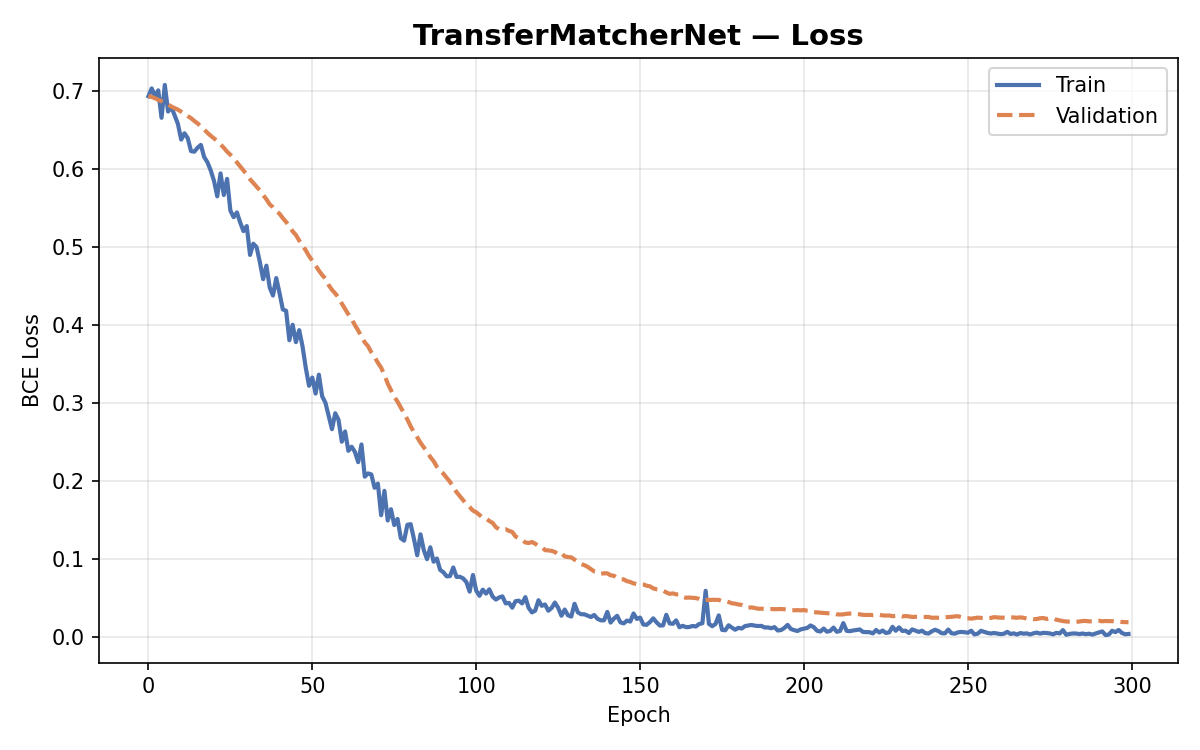

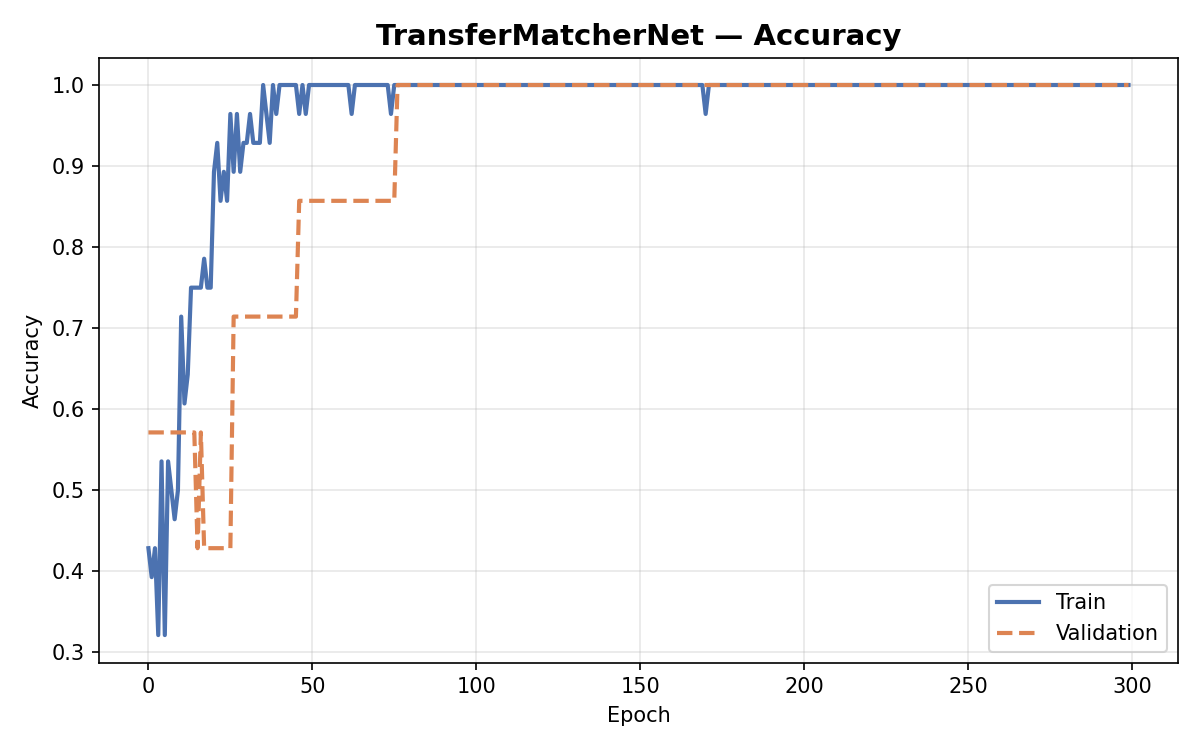

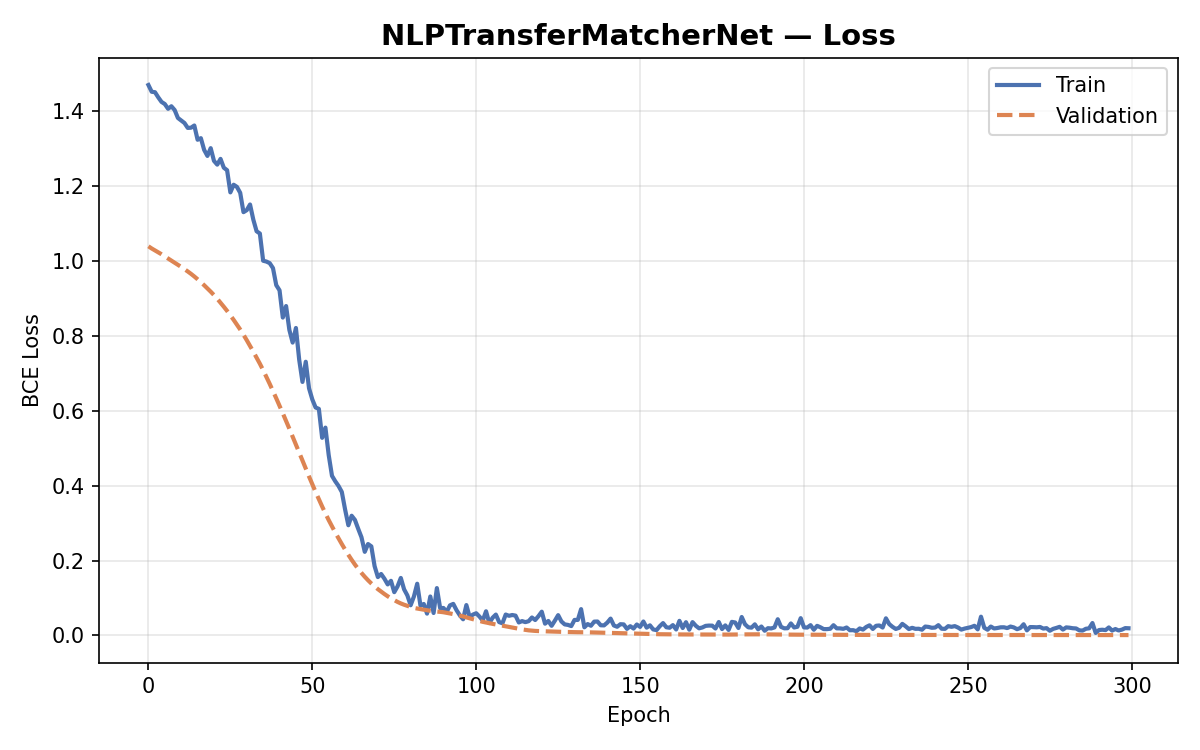

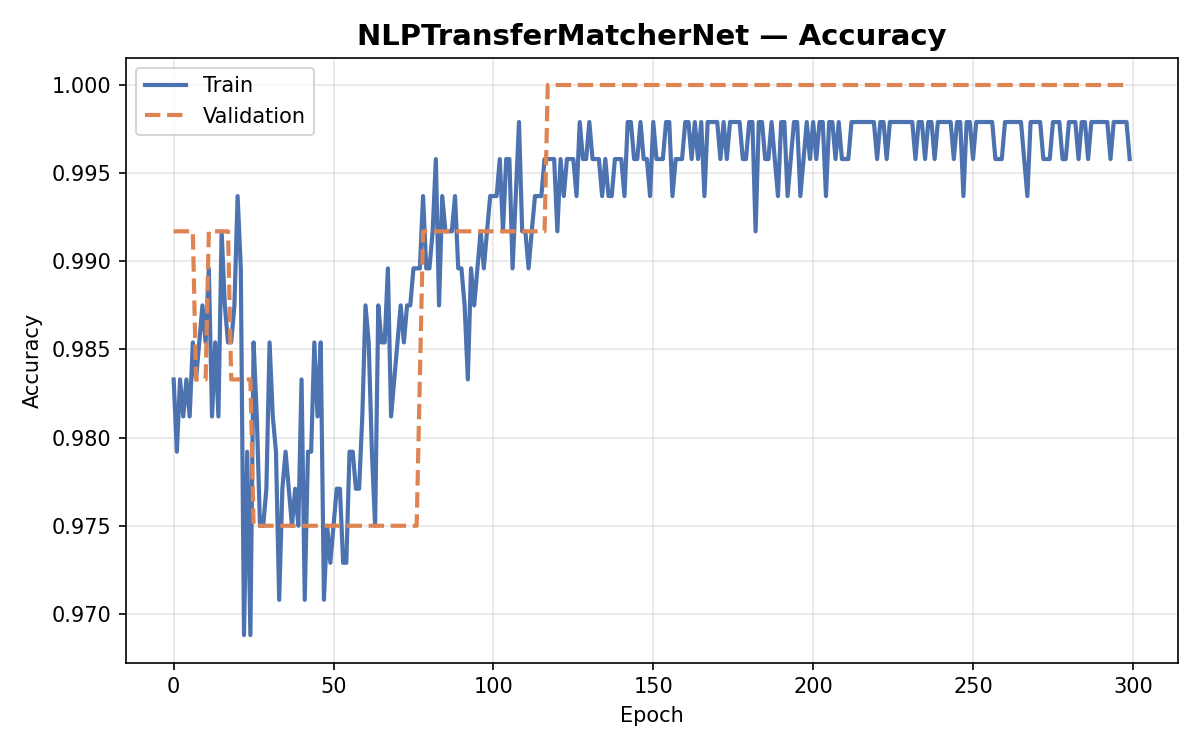

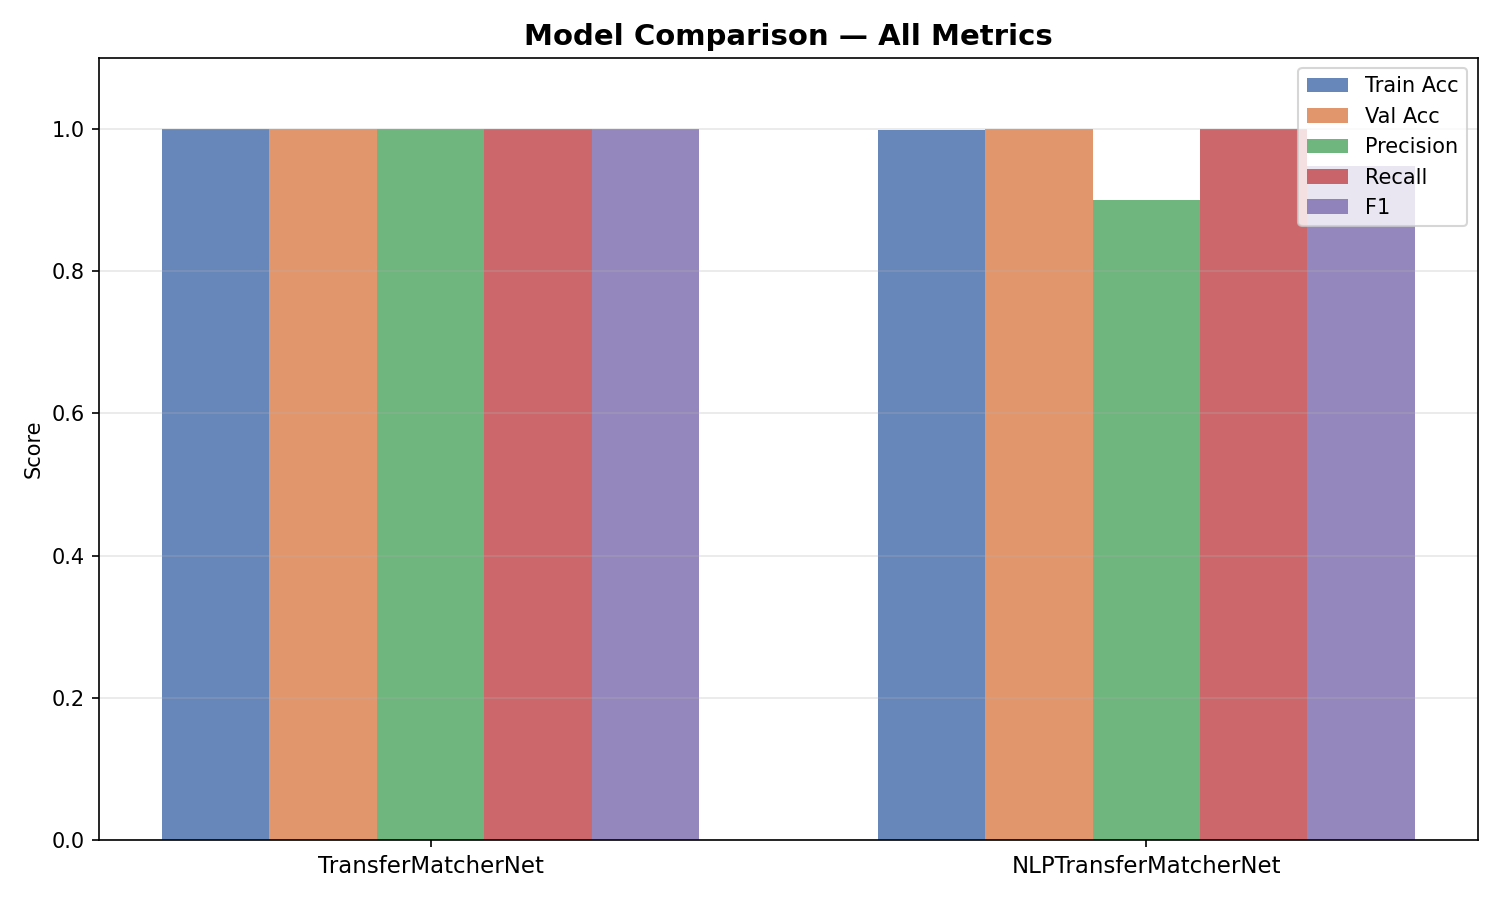

In [26]:
from IPython.display import Image, display

display(Image("structured_loss_curve.png"))
display(Image("structured_accuracy_curve.png"))
display(Image("nlp_loss_curve.png"))
display(Image("nlp_accuracy_curve.png"))
display(Image("model_comparison_bar_chart.png"))

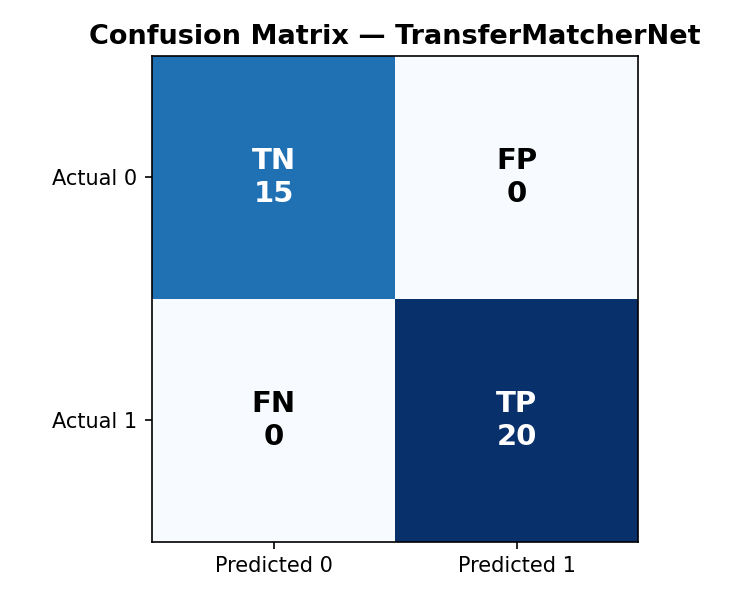

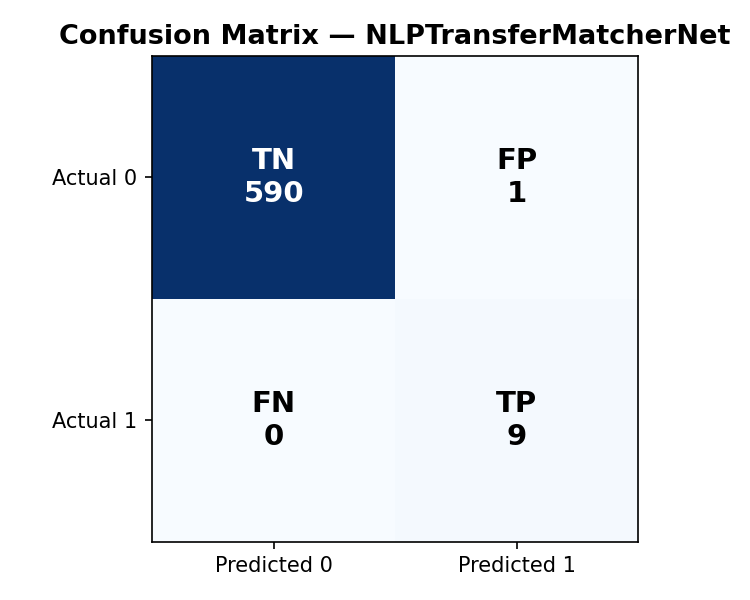

In [28]:
display(Image("confusion_matrix_structured.png"))
display(Image("confusion_matrix_nlp.png"))

## Results Analysis

The experimental results show that both neural network architectures achieved strong performance for transfer course equivalency prediction.

TransferMatcherNet performed well using engineered structured academic features such as:
- subject similarity
- course level
- credit comparison
- one-hot encoded subject categories

NLPTransferMatcherNet achieved highly stable performance using:
- Knowledge Unit overlap
- TF-IDF semantic similarity
- course title similarity

The NLP-based model demonstrated stronger consistency across multiple independent trials, suggesting that semantic curriculum information improves transfer equivalency prediction.

## Conclusion

This project successfully developed and evaluated a deep learning-based transfer course equivalency prediction system.

Two neural network architectures were implemented:
- TransferMatcherNet using structured academic features
- NLPTransferMatcherNet using semantic similarity and Knowledge Units

The project implemented several important deep learning techniques including:
- feature normalization
- dropout regularization
- Batch Normalization
- weighted loss functions
- early stopping
- learning rate scheduling
- evaluation metrics
- visualization methods

The final results demonstrated strong predictive performance and successful comparison between structured and semantic deep learning approaches.

## Use of Generative AI

Generative AI tools were used during the development of this project to assist with:
- code organization
- debugging
- documentation
- visualization setup
- notebook formatting
- evaluation metric implementation

All model design decisions, dataset preparation, experimentation, testing, and final evaluation were reviewed and validated by the project author.